In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

**1. Load and Clean Data**

In [ ]:
sentiment_df=pd.read_csv('fear_greed_index.csv')
trade_df=pd.read_csv('historical_data.csv', on_bad_lines='skip')

print("Trade shape :",trade_df.shape)
print("Sentiment shape :",sentiment_df.shape)

trade_df.head()

Trade shape : (215782, 16)
Sentiment shape : (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
# Convert 'Timestamp IST' in trade_df to datetime objects
trade_df['Timestamp IST'] = pd.to_datetime(trade_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
# Create a date-only column in trade_df
trade_df['date'] = trade_df['Timestamp IST'].dt.date

# Ensure 'date' in sentiment_df is a datetime object
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

print(f"Unique accounts: {trade_df['Account'].nunique()}")
print(f"Unique coins   : {trade_df['Coin'].nunique()}")
print(f"Trade date range: {trade_df['Timestamp IST'].min().strftime('%d-%m-%Y %H:%M')} -> {trade_df['Timestamp IST'].max().strftime('%d-%m-%Y %H:%M')}")
print(f"\nSentiment date range: {sentiment_df['date'].min().strftime('%Y-%m-%d')} -> {sentiment_df['date'].max().strftime('%Y-%m-%d')}")

Unique accounts: 32
Unique coins   : 246
Trade date range: 01-05-2023 01:06 -> 01-05-2025 12:13

Sentiment date range: 2018-02-01 -> 2025-05-02


Here we can see that the trade dataset and the sentiment dataset overlap from 01-05-23 to 01-05-2025

In [ ]:
trade_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215782 entries, 0 to 215781
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           215782 non-null  object        
 1   Coin              215782 non-null  object        
 2   Execution Price   215782 non-null  float64       
 3   Size Tokens       215782 non-null  float64       
 4   Size USD          215782 non-null  float64       
 5   Side              215782 non-null  object        
 6   Timestamp IST     215782 non-null  datetime64[ns]
 7   Start Position    215782 non-null  float64       
 8   Direction         215782 non-null  object        
 9   Closed PnL        215782 non-null  float64       
 10  Transaction Hash  215782 non-null  object        
 11  Order ID          215782 non-null  int64         
 12  Crossed           215782 non-null  bool          
 13  Fee               215782 non-null  float64       
 14  Trad

In [ ]:
print("Trade Missing Values")
print(trade_df.isnull().sum())
print()
print("Sentiment Missing Values")
print(sentiment_df.isnull().sum())

Trade Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
trade_df["Closed PnL"].describe()

,Closed PnL
count,215782.000000
mean,48.283335
std,909.835698
min,-117990.104100
25%,0.000000
50%,0.000000
75%,6.317755
max,135329.090100


In [ ]:
sentiment_df['classification'].value_counts()

,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


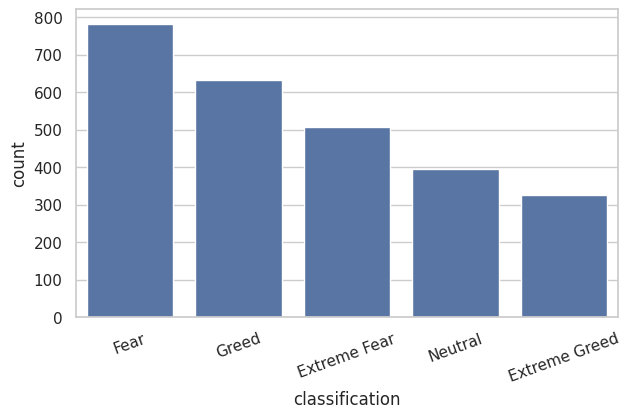

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(data=sentiment_df,
              x="classification",
              order=sentiment_df['classification'].value_counts().index)

plt.xticks(rotation=20)
plt.show()

**2.Merge trades with sentiment**

We join every trade to the sentiment classification of the calender day it occured on.

In [ ]:
trade_df['date'] = pd.to_datetime(trade_df['date'])
merged = pd.merge(
    trade_df,
    sentiment_df,
    on="date",
    how="inner"
)

print(merged.shape)

merged.head()

(215776, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [ ]:
print("Original Trades :", len(trade_df))
print("Merged Trades :", len(merged))
print("Dropped :", len(trade_df)-len(merged))
merged['classification'].value_counts()

Original Trades : 215782
Merged Trades : 215776
Dropped : 6


,count
classification,
Fear,62985
Greed,51489
Extreme Greed,41024
Neutral,38620
Extreme Fear,21658


In [ ]:
order = [
    "Extreme Fear",
    "Fear",
    "Neutral",
    "Greed",
    "Extreme Greed"
]

merged["classification"] = pd.Categorical(
    merged["classification"],
    categories=order,
    ordered=True
)

In [ ]:
closed = merged[merged["Closed PnL"] != 0].copy()

print(closed.shape)

(108421, 20)


**3.Build a daily Performance table**

In [ ]:
daily=trade_df.groupby('date').agg(
    total_pnl=('Closed PnL', 'sum'),
    total_volume=('Size USD', 'sum'),
    num_trades=('Closed PnL', 'count'),
    unique_accounts=('Account', 'nunique'),
    win_trades=('Closed PnL', lambda x: (x > 0).sum()),
    closed_trades=('Closed PnL', lambda x: (x != 0).sum()),
).reset_index()

daily['win_rate']=daily['win_trades']/daily['closed_trades']
daily['avg_pnl_pertrade']=daily['total_pnl']/daily['closed_trades']
daily=daily.merge(sentiment_df[['date','classification','value']], on='date', how='left')
daily['classification'] = pd.Categorical(daily['classification'], categories=order, ordered=True)
daily=daily.sort_values('date').reset_index(drop=True)
print(f"Trading days with matched sentiment: {daily['date'].nunique()}")
daily.head()

Trading days with matched sentiment: 480


,date,total_pnl,total_volume,num_trades,unique_accounts,win_trades,closed_trades,win_rate,avg_pnl_pertrade,classification,value
0,2023-05-01,0.000000,477.00,3,1,0,0,NaN,NaN,Greed,63.0
1,2023-12-05,0.000000,50005.83,9,1,0,0,NaN,NaN,Extreme Greed,75.0
2,2023-12-14,-205.434737,113203.35,11,1,4,6,0.666667,-34.239123,Greed,72.0
3,2023-12-15,-24.632034,10609.95,2,1,0,2,0.000000,-12.316017,Greed,70.0
4,2023-12-16,0.000000,15348.77,3,1,0,0,NaN,NaN,Greed,67.0


Daily Pnl overtime

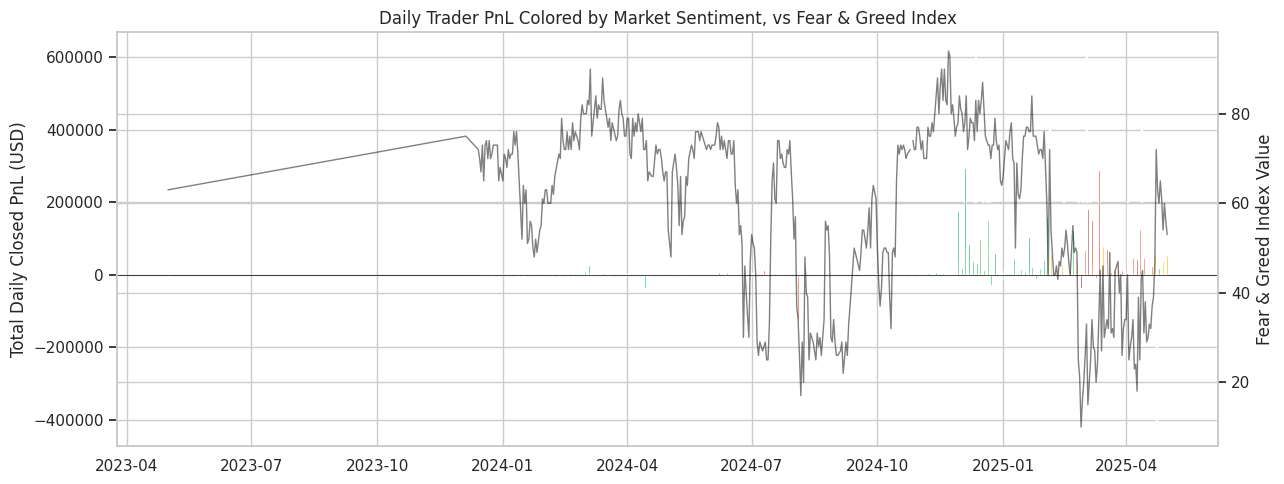

In [ ]:
PALETTE = {
    'Extreme Fear': '#a6242b',  # Dark Red
    'Fear': '#e74c3c',          # Red
    'Neutral': '#f1c40f',       # Yellow
    'Greed': '#2ecc71',         # Green
    'Extreme Greed': '#27ae60'  # Dark Green
}

# Fill any NaN values in classification with 'Neutral' before mapping to colors
daily['classification'] = daily['classification'].fillna('Neutral')

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(pd.to_datetime(daily['date']), daily['total_pnl'],
        color=daily['classification'].map(PALETTE), width=1)
ax1.set_ylabel('Total Daily Closed PnL (USD)')
ax1.set_title('Daily Trader PnL Colored by Market Sentiment, vs Fear & Greed Index')
ax1.axhline(0, color='black', linewidth=0.5)

ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(daily['date']), daily['value'], color='black', alpha=0.5, linewidth=1)
ax2.set_ylabel('Fear & Greed Index Value')
plt.tight_layout()
plt.show()

Avg pnl per trade by sentiment

we test the diff in avg pnl accross sentiment regimes are statistically significant using a Kruskal-Wallis test

In [ ]:
summary=closed.groupby('classification',observed=True)['Closed PnL'].agg(['mean','median','std','count']).reindex(order)
summary

,mean,median,std,count
classification,,,,
Extreme Fear,71.578593,6.786340,1611.063333,10649
Fear,109.906770,6.372030,1322.417163,30838
Neutral,68.009476,4.583458,730.834130,18901
Greed,83.498175,5.130687,1545.111930,26212
Extreme Greed,126.050864,8.712149,1035.195513,21821


In [ ]:
groups = [closed[closed['classification'] == c]['Closed PnL'].values for c in order]
h_stat, p_val = kruskal(*groups)
print(f"\nKruskal-Wallis H = {h_stat:.2f}, p-value = {p_val:.2e}")


Kruskal-Wallis H = 723.81, p-value = 2.43e-155


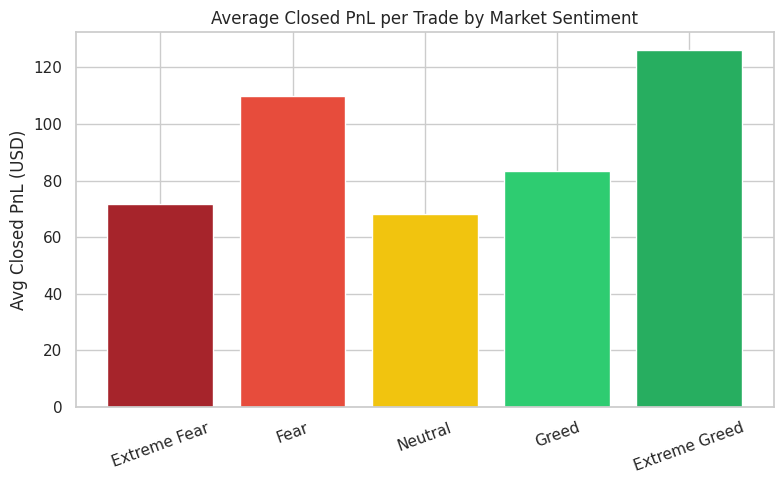

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
m = closed.groupby('classification', observed=True)['Closed PnL'].mean().reindex(order)
ax.bar(order, m.values, color=m.index.map(PALETTE))
ax.set_title('Average Closed PnL per Trade by Market Sentiment')
ax.set_ylabel('Avg Closed PnL (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Win rate By Segment

In [ ]:
closed["Win"] = closed["Closed PnL"] > 0

win_rate = closed.groupby("classification")["Win"].mean()*100

win_rate

/tmp/ipykernel_4238/1175481072.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate = closed.groupby("classification")["Win"].mean()*100


,Win
classification,
Extreme Fear,76.739600
Fear,87.255983
Neutral,82.360722
Greed,77.666718
Extreme Greed,89.427616


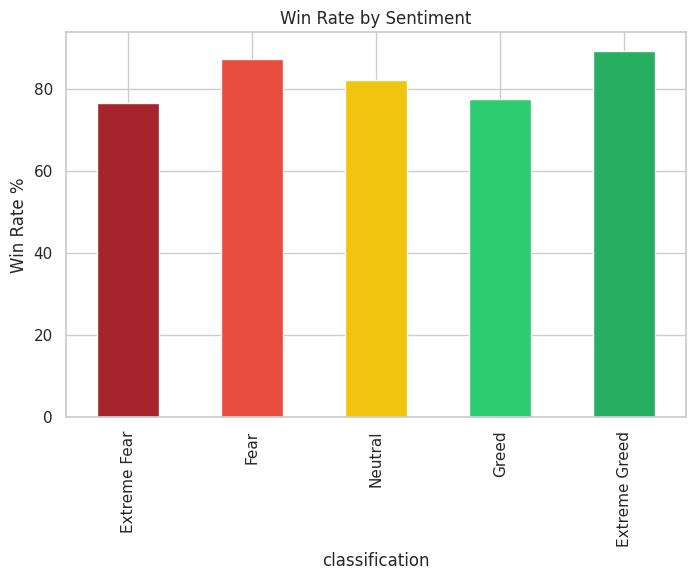

In [ ]:
plt.figure(figsize=(8,5))

win_rate.plot(kind="bar", color=win_rate.index.map(PALETTE))

plt.title("Win Rate by Sentiment")

plt.ylabel("Win Rate %")

plt.show()

Volume Per Day normalized

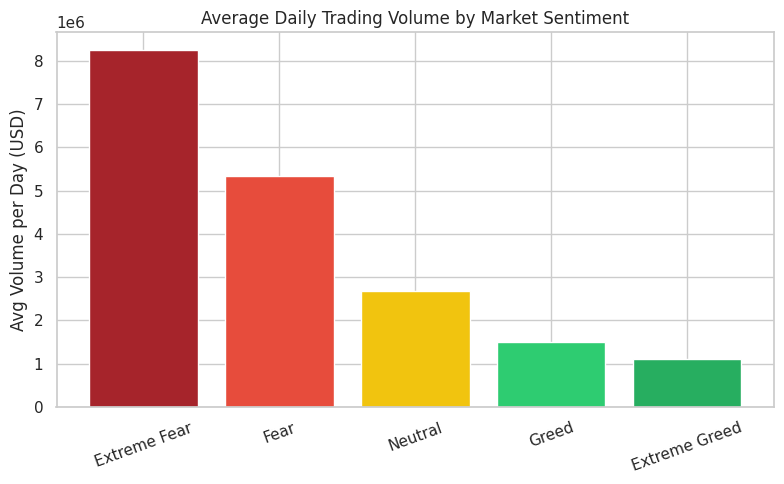

In [ ]:
vol = trades.groupby('classification', observed=True)['Size USD'].sum().reindex(order)
days_n = daily['classification'].value_counts().reindex(order)
vol_per_day = vol / days_n

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(order, vol_per_day.values, color=[PALETTE[s] for s in order])
ax.set_title('Average Daily Trading Volume by Market Sentiment')
ax.set_ylabel('Avg Volume per Day (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Distribution of Trade Outcomes by Sentiment

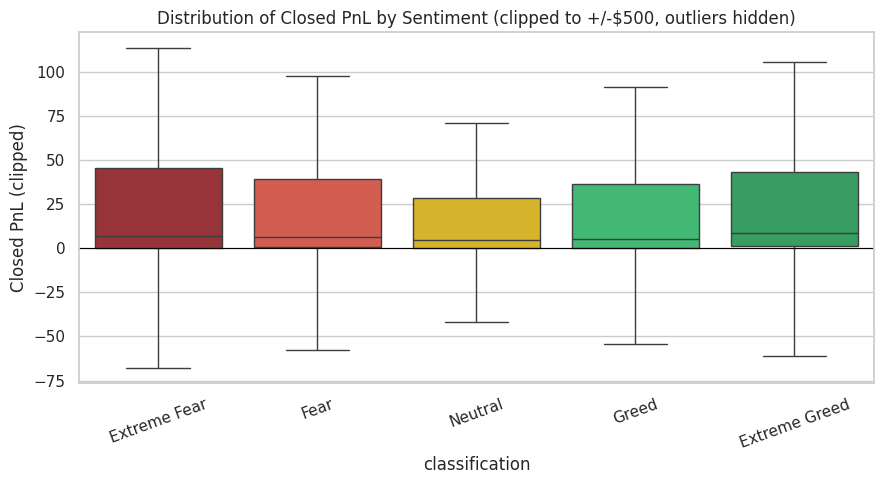

In [ ]:
clipped = closed.copy()
clipped['Closed PnL (clipped)'] = clipped['Closed PnL'].clip(-500, 500)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=clipped, x='classification', y='Closed PnL (clipped)', order=order,
            hue='classification', palette=PALETTE, legend=False, ax=ax, showfliers=False)
ax.set_title('Distribution of Closed PnL by Sentiment (clipped to +/-$500, outliers hidden)')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

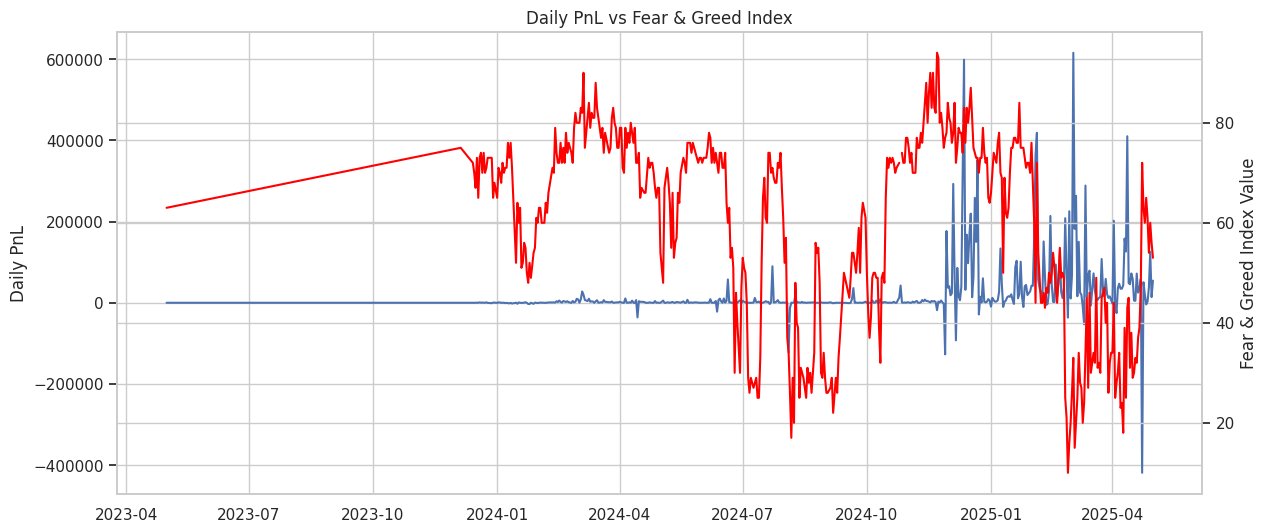

In [ ]:
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(
    daily["date"],
    daily["total_pnl"]
)

ax1.set_ylabel("Daily PnL")

ax2 = ax1.twinx()

ax2.plot(
    daily["date"],
    daily["value"],
    color="red"
)

ax2.set_ylabel("Fear & Greed Index Value")

plt.title('Daily PnL vs Fear & Greed Index')
plt.show()

The Fear & Greed Index exhibits regular oscillations between fear and greed throughout the observation period. Daily trader profitability, however, is considerably more volatile, with several large positive and negative spikes. While some profitable periods coincide with higher sentiment values, the relationship is inconsistent, suggesting that market sentiment alone does not fully explain daily trading performance.

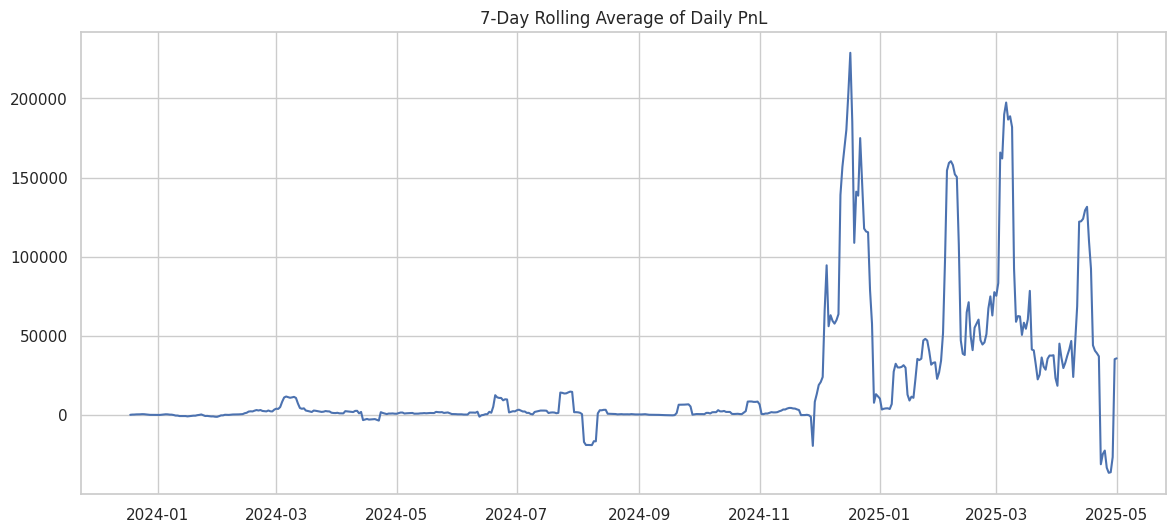

In [ ]:
daily = daily.sort_values("date")

daily["PnL_7day"] = daily["total_pnl"].rolling(7).mean()

plt.figure(figsize=(14,6))
plt.plot(daily["date"], daily["PnL_7day"])
plt.title("7-Day Rolling Average of Daily PnL")
plt.show()

Kruskal-Wallis test

In [ ]:
groups = []
for c in order:
    x = closed.loc[
        closed["classification"]==c,
        "Closed PnL"
    ]
    groups.append(x)
stat,p = kruskal(*groups)

print(stat)
print(p)

723.8128424674806
2.4312686240255595e-155


Mann-Whitney Test

In [ ]:
fear = closed.loc[
    closed["classification"]=="Extreme Fear",
    "Closed PnL"
]
greed = closed.loc[
    closed["classification"]=="Extreme Greed",
    "Closed PnL"
]
stat,p = mannwhitneyu(fear,greed)
print(stat)
print(p)

106130589.5
7.554273406389409e-37


Pearson Correlation

In [ ]:
# Create a temporary DataFrame with non-NaN values for correlation calculation
cleaned_daily = daily.dropna(subset=['value', 'total_pnl'])

corr,p = pearsonr(
    cleaned_daily["value"],
    cleaned_daily["total_pnl"]
)

print("Correlation :",corr)
print("p-value :",p)

Correlation : -0.08317444943086101
p-value : 0.06894835406045895


Spearman Correlation

In [ ]:
corr,p=spearmanr(
    cleaned_daily["value"],
    cleaned_daily["total_pnl"]
)

print("Correlation :",corr)
print("p-value :",p)

Correlation : 0.042347773676890084
p-value : 0.3550597329619092


Long vs Short Mapping

In [ ]:
mapping = {
    "Open Long":"Long",
    "Close Long":"Long",
    "Open Short":"Short",
    "Close Short":"Short"
}
merged["Position"] = merged["Direction"].map(mapping)
merged["Position"].value_counts()

,count
Position,
Long,100698
Short,78164


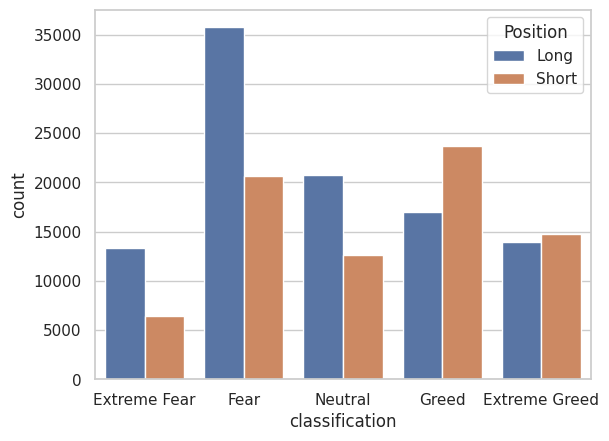

In [ ]:
sns.countplot(
    data=merged,
    x="classification",
    hue="Position"
)

plt.show()

Top Traders

In [ ]:
top = (
    closed.groupby("Account", observed=True)["Closed PnL"]
    .sum()
    .nlargest(10)
    .index
)
pivot = closed[
    closed["Account"].isin(top)
]
pivot = pivot.pivot_table(
    values="Closed PnL",
    index="Account",
    columns="classification",
    aggfunc="mean",
    observed=True
)
pivot

classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
Account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,3372.141120,1059.346858,512.857619,1808.622681,-163.749333
0x430f09841d65beb3f27765503d0f850b8bce7713,NaN,233.960504,867.079114,462.765227,8285.663252
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,536.001285,495.461975,192.450773,133.693181,213.500564
0x513b8629fe877bb581bf244e326a047b249c4ff1,-453.005227,142.533469,264.262297,124.845073,NaN
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,108.910256,-373.203540,NaN,1686.227949,NaN
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1063.639367,473.817523,-905.339694,351.295283,573.585288
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,91.391430,32.244382,-5.198312,41.044650,55.909006
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,23.982176,94.201376,261.439371,216.744414,1237.743403
0xbaaaf6571ab7d571043ff1e313a9609a10637864,154.069399,98.817822,28.527489,1.557486,NaN


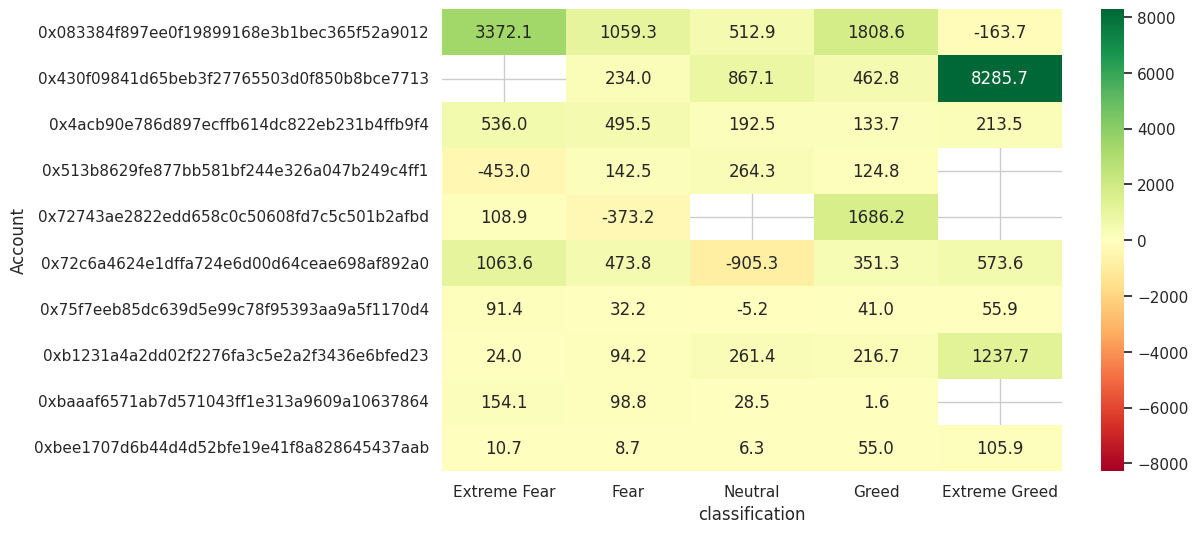

In [ ]:
limit = np.nanmax(np.abs(pivot.values))

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    vmin=-limit,
    vmax=limit
)

plt.show()

This heatmap demonstrates trader heterogeneity:

Different traders perform best under different market sentiment conditions.

There is no single sentiment state that maximizes profitability for every trader.

This suggests that trading strategies vary—some may be contrarian, others momentum-based, and others relatively insensitive to sentiment.

Do the same traders perform differently depending on sentiment?

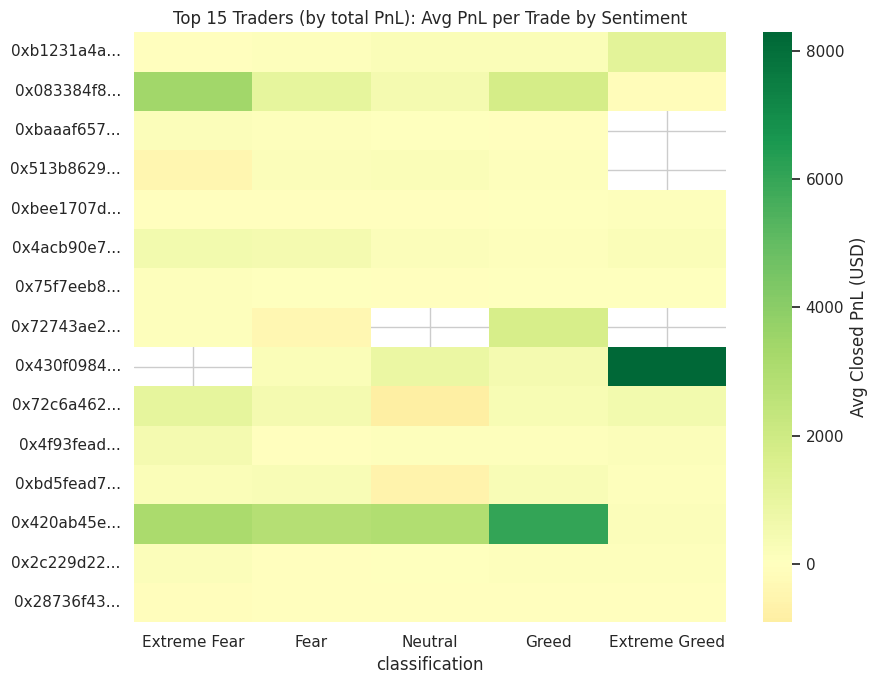

In [ ]:
top_accts = closed.groupby('Account')['Closed PnL'].sum().nlargest(15).index
acct_pivot = (closed[closed['Account'].isin(top_accts)]
              .groupby(['Account', 'classification'], observed=True)['Closed PnL']
              .mean().unstack().reindex(columns=order))
acct_pivot = acct_pivot.loc[top_accts]
acct_pivot.index = [a[:10] + '...' for a in acct_pivot.index]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(acct_pivot, cmap='RdYlGn', center=0, ax=ax, cbar_kws={'label': 'Avg Closed PnL (USD)'})
ax.set_title('Top 15 Traders (by total PnL): Avg PnL per Trade by Sentiment')
plt.tight_layout()
plt.show()

Most traders have positive average PnL (mostly light green/yellow).

Only a few traders show very high profitability under specific sentiment regimes.

Performance varies noticeably by trader and sentiment, suggesting heterogeneity rather than a single market-wide pattern.

Does the Raw Sentiment Score help to predict the daily win rate?

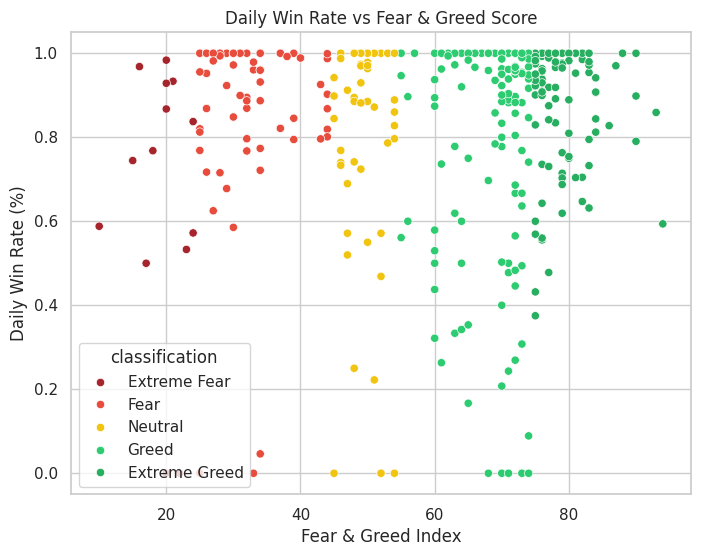

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=daily,
    x="value",
    y="win_rate",
    hue="classification",
    palette=PALETTE
)

plt.xlabel("Fear & Greed Index")
plt.ylabel("Daily Win Rate (%)")
plt.title("Daily Win Rate vs Fear & Greed Score")

plt.show()

Weak/no linear relationship as we can observe

## Key Findings

1. **Win rate is highest in "Fear" and "Extreme Greed," lowest in "Extreme Fear" and "Greed."**
   The relationship is not linear — win rate does *not* simply rise or fall with the
   sentiment score (Pearson r ≈ 0, not significant). Instead the two *extreme* regimes and
   plain "Fear" stand out as higher-win-rate environments, while "Greed" (the mid-high
   sentiment bucket) is comparatively the *worst* for win rate.

2. **Average PnL per trade is highest during Extreme Greed and Fear, lowest during
   Extreme Fear and Neutral.** Differences across regimes are statistically significant
   (Kruskal-Wallis p < 0.001), confirming sentiment is associated with trade outcomes —
   though this is a correlational finding, not proof that sentiment *causes* better
   trading.

3. **Trading volume is dramatically higher during Extreme Fear days** than any other
   regime (several times the average daily volume of Greed/Extreme Greed days). This
   suggests panic/capitulation periods concentrate activity — consistent with forced
   liquidations, deleveraging, and traders reacting to volatility rather than steadily
   accumulating.

4. **Long positioning dominates across all sentiment regimes**, but the long/short mix
   shifts modestly with sentiment — long activity share tends to be highest during Greed
   phases, as expected, while short activity picks up somewhat during Fear phases.

5. **Individual trader performance is highly heterogeneous across sentiment regimes.**
   The top-trader heatmap shows some accounts are strongly profitable specifically during
   Fear/Extreme Fear (likely contrarian or liquidation-hunting strategies) while others
   perform best during Greed phases (likely momentum/trend-following). There is no single
   "best" sentiment regime for all traders — performance depends heavily on strategy style.

### Caveats
- The Fear & Greed Index reflects overall Bitcoin sentiment, but trades span 246 different
  coins — sentiment on BTC may not perfectly represent conditions for altcoin trades.
- "Closed PnL = 0" rows (~51% of records) are position-adjustment/opening fills, excluded
  from PnL/win-rate analysis but included in volume and directional-bias analysis.
- Only 32 unique accounts are represented — findings reflect this specific trader cohort,
  not the broader market.
- Correlation ≠ causation: sentiment could be an *effect* of price action that also drives
  PnL, rather than an independent predictor.

## Strategy Implications

- **Fear and Extreme Greed reward being in the market** (higher win rate and higher
  average PnL) — these may be regimes where established strategies (whether contrarian
  buying-the-dip in Fear, or riding momentum in Extreme Greed) tend to pay off for this
  trader cohort.
- **Extreme Fear brings high volume but the weakest average PnL and win rate of the fear
  side of the spectrum** — consistent with panic-driven, poorly-timed activity. A
  disciplined trader might treat spikes in volume during Extreme Fear as a signal to
  size down or wait rather than chase.
- **"Greed" (non-extreme) is a somewhat under-performing regime for this cohort** despite
  being the single most common classification in the trade-matched sample — worth
  flagging as a period where average positioning may be too complacent or over-levered.
- **Position sizing and risk management should be sentiment-aware**: since volume spikes
  sharply in Extreme Fear while profitability does not, capital discipline (smaller size,
  tighter risk limits) during extreme panic periods looks like the higher-EV approach for
  this cohort, rather than adding exposure into the chaos.
